# Position-wise Probing at Layer 5

This notebook follows up on the main probing experiment (`probing_experiment.ipynb`). It uses the **same dataset and classifier settings**, but instead of varying the layer, it fixes **layer 5** and varies the **token position** from which we read the hidden state.

For `noun1`, `verb`, `noun2`, `was`, and `by` we feed the **plain sentence without markers** — since we read directly from the relevant token, no marking is needed. For the `final` token we use the **marked sentence** (with `<tgt>` markers), identical to the original notebook, because the final token needs the markers to know which noun is the target.

**Positions probed:** `noun1` (subject), `verb`, `noun2` (object / post-*by* NP), `final` (marked), and for passives `was` / `by`.

**Example subsets per probe:**

| Probe | Examples used | N |
|-------|-------------|---|
| noun1 | Active+Agent ∪ Passive+Patient | 76 |
| verb  | Active+Agent ∪ Passive+Patient | 76 |
| noun2 | Active+Patient ∪ Passive+Agent | 76 |
| final | All (marked sentence) | 152 |
| was   | All passive | 76 |
| by    | All passive | 76 |

## Quick check if I'm connected to the colab GPU kernel (T4)

In [1]:
import os
import sys

print("python_executable:", sys.executable)
print("google.colab in modules:", "google.colab" in sys.modules)
print("COLAB_GPU env:", os.environ.get("COLAB_GPU"))

# Estimate system RAM without extra dependencies
try:
    page_size = os.sysconf("SC_PAGE_SIZE")
    phys_pages = os.sysconf("SC_PHYS_PAGES")
    total_gb = (page_size * phys_pages) / (1024 ** 3)
    print(f"system_ram_gb: {total_gb:.2f}")
except Exception as e:
    print("ram_check_error:", str(e))

try:
    import torch
    print("torch_version:", torch.__version__)
    print("cuda_available:", torch.cuda.is_available())
    if torch.cuda.is_available():
        print("gpu_name:", torch.cuda.get_device_name(0))
except Exception as e:
    print("torch_check_error:", str(e))

# Lightweight Aya availability check (config + tokenizer only, no 8B weights)
try:
    from transformers import AutoConfig, AutoTokenizer
    cfg = AutoConfig.from_pretrained("CohereForAI/aya-expanse-8b")
    tok = AutoTokenizer.from_pretrained("CohereForAI/aya-expanse-8b")
    print("aya_config_loaded:", True)
    print("aya_model_type:", getattr(cfg, "model_type", "unknown"))
    print("aya_tokenizer_vocab_size:", len(tok))
except Exception as e:
    print("aya_lightweight_check_error:", str(e))

print("estimated_fp32_memory_for_8b_params_gb: ~32+")
print("estimated_fp16_memory_for_8b_params_gb: ~16+ (plus overhead)")

python_executable: /usr/bin/python3
google.colab in modules: True
COLAB_GPU env: 1
system_ram_gb: 12.67
torch_version: 2.10.0+cu128
cuda_available: True
gpu_name: Tesla T4
aya_lightweight_check_error: You are trying to access a gated repo.
Make sure to have access to it at https://huggingface.co/CohereForAI/aya-expanse-8b.
401 Client Error. (Request ID: Root=1-69dc983f-17b77a0f044e8d1e2ce1321a;430ee1f0-8947-455b-aeda-0347efa815d0)

Cannot access gated repo for url https://huggingface.co/CohereForAI/aya-expanse-8b/resolve/main/config.json.
Access to model CohereLabs/aya-expanse-8b is restricted. You must have access to it and be authenticated to access it. Please log in.
estimated_fp32_memory_for_8b_params_gb: ~32+
estimated_fp16_memory_for_8b_params_gb: ~16+ (plus overhead)


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:104: UserWarning: 
Error while fetching `HF_TOKEN` secret value from your vault: 'Requesting secret HF_TOKEN timed out. Secrets can only be fetched when running from the Colab UI.'.
You are not authenticated with the Hugging Face Hub in this notebook.
If the error persists, please let us know by opening an issue on GitHub (https://github.com/huggingface/huggingface_hub/issues/new).
  warnings.warn(


In [2]:
# Hugging Face authentication for gated Aya model access
# Run this once per new kernel session.
from getpass import getpass
from huggingface_hub import login
from transformers import AutoConfig

token = getpass("Paste your Hugging Face read token, then press Enter: ").strip()
if not token:
    raise ValueError("No token entered. Please rerun this cell and paste your token.")
if not token.startswith("hf_"):
    raise ValueError("Token format looks invalid. It should usually start with 'hf_'.")

login(token=token, add_to_git_credential=False)
# Quick access check for the gated model
cfg = AutoConfig.from_pretrained("CohereForAI/aya-expanse-8b")
print("Hugging Face auth OK. Model type:", cfg.model_type)

config.json:   0%|          | 0.00/634 [00:00<?, ?B/s]

Hugging Face auth OK. Model type: cohere


In [3]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from typing import Dict, List, Optional, Tuple
from transformers import AutoModelForCausalLM, AutoTokenizer
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score, train_test_split
from sklearn.preprocessing import LabelEncoder

In [4]:
def load_model_and_tokenizer(
    model_name: str = "CohereForAI/aya-expanse-8b",
    device: Optional[str] = None,
) -> Tuple[AutoModelForCausalLM, AutoTokenizer, str]:
    if device is None:
        device = "cuda" if torch.cuda.is_available() else "cpu"

    print(f"Loading tokenizer for '{model_name}'...")
    tokenizer = AutoTokenizer.from_pretrained(model_name)

    print(f"Loading model on device: {device}")
    model = AutoModelForCausalLM.from_pretrained(
        model_name,
        output_hidden_states=True,
        torch_dtype=torch.float16 if device == "cuda" else torch.float32,
        device_map="auto" if device == "cuda" else None,
    )
    model.eval()
    print("Model loaded successfully.")
    return model, tokenizer, device


def mark_target_in_sentence(sentence: str, target_word: str) -> str:
    lower_sentence = sentence.lower()
    lower_target = target_word.lower()
    start = lower_sentence.find(lower_target)
    if start == -1:
        raise ValueError(f"Target word '{target_word}' not found in sentence: '{sentence}'")

    end = start + len(target_word)
    return sentence[:start] + f"<tgt> {sentence[start:end]} </tgt>" + sentence[end:]


def create_dataset() -> List[Tuple[str, str, str]]:
    examples = [
        ("The dog chased the cat.", "dog", "Agent"),
        ("The dog chased the cat.", "cat", "Patient"),
        ("The cat was chased by the dog.", "cat", "Patient"),
        ("The cat was chased by the dog.", "dog", "Agent"),
        ("The cat scratched the dog.", "cat", "Agent"),
        ("The cat scratched the dog.", "dog", "Patient"),
        ("The dog was scratched by the cat.", "dog", "Patient"),
        ("The dog was scratched by the cat.", "cat", "Agent"),
        ("The man saw the woman.", "man", "Agent"),
        ("The man saw the woman.", "woman", "Patient"),
        ("The woman was seen by the man.", "woman", "Patient"),
        ("The woman was seen by the man.", "man", "Agent"),
        ("The woman helped the man.", "woman", "Agent"),
        ("The woman helped the man.", "man", "Patient"),
        ("The man was helped by the woman.", "man", "Patient"),
        ("The man was helped by the woman.", "woman", "Agent"),
        ("The child found the teacher.", "child", "Agent"),
        ("The child found the teacher.", "teacher", "Patient"),
        ("The teacher was found by the child.", "teacher", "Patient"),
        ("The teacher was found by the child.", "child", "Agent"),
        ("The teacher scolded the child.", "teacher", "Agent"),
        ("The teacher scolded the child.", "child", "Patient"),
        ("The child was scolded by the teacher.", "child", "Patient"),
        ("The child was scolded by the teacher.", "teacher", "Agent"),
        ("The bird spotted the fox.", "bird", "Agent"),
        ("The bird spotted the fox.", "fox", "Patient"),
        ("The fox was spotted by the bird.", "fox", "Patient"),
        ("The fox was spotted by the bird.", "bird", "Agent"),
        ("The fox chased the bird.", "fox", "Agent"),
        ("The fox chased the bird.", "bird", "Patient"),
        ("The bird was chased by the fox.", "bird", "Patient"),
        ("The bird was chased by the fox.", "fox", "Agent"),
        ("The student greeted the professor.", "student", "Agent"),
        ("The student greeted the professor.", "professor", "Patient"),
        ("The professor was greeted by the student.", "professor", "Patient"),
        ("The professor was greeted by the student.", "student", "Agent"),
        ("The professor praised the student.", "professor", "Agent"),
        ("The professor praised the student.", "student", "Patient"),
        ("The student was praised by the professor.", "student", "Patient"),
        ("The student was praised by the professor.", "professor", "Agent"),
        ("The lion caught the zebra.", "lion", "Agent"),
        ("The lion caught the zebra.", "zebra", "Patient"),
        ("The zebra was caught by the lion.", "zebra", "Patient"),
        ("The zebra was caught by the lion.", "lion", "Agent"),
        ("The zebra kicked the lion.", "zebra", "Agent"),
        ("The zebra kicked the lion.", "lion", "Patient"),
        ("The lion was kicked by the zebra.", "lion", "Patient"),
        ("The lion was kicked by the zebra.", "zebra", "Agent"),
        ("The doctor examined the nurse.", "doctor", "Agent"),
        ("The doctor examined the nurse.", "nurse", "Patient"),
        ("The nurse was examined by the doctor.", "nurse", "Patient"),
        ("The nurse was examined by the doctor.", "doctor", "Agent"),
        ("The nurse assisted the doctor.", "nurse", "Agent"),
        ("The nurse assisted the doctor.", "doctor", "Patient"),
        ("The doctor was assisted by the nurse.", "doctor", "Patient"),
        ("The doctor was assisted by the nurse.", "nurse", "Agent"),
        ("The cat caught the mouse.", "cat", "Agent"),
        ("The cat caught the mouse.", "mouse", "Patient"),
        ("The mouse was caught by the cat.", "mouse", "Patient"),
        ("The mouse was caught by the cat.", "cat", "Agent"),
        ("The mouse bit the cat.", "mouse", "Agent"),
        ("The mouse bit the cat.", "cat", "Patient"),
        ("The cat was bitten by the mouse.", "cat", "Patient"),
        ("The cat was bitten by the mouse.", "mouse", "Agent"),
        ("The boy pushed the girl.", "boy", "Agent"),
        ("The boy pushed the girl.", "girl", "Patient"),
        ("The girl was pushed by the boy.", "girl", "Patient"),
        ("The girl was pushed by the boy.", "boy", "Agent"),
        ("The girl hugged the boy.", "girl", "Agent"),
        ("The girl hugged the boy.", "boy", "Patient"),
        ("The boy was hugged by the girl.", "boy", "Patient"),
        ("The boy was hugged by the girl.", "girl", "Agent"),
        ("The wolf frightened the deer.", "wolf", "Agent"),
        ("The wolf frightened the deer.", "deer", "Patient"),
        ("The deer was frightened by the wolf.", "deer", "Patient"),
        ("The deer was frightened by the wolf.", "wolf", "Agent"),
        ("The deer kicked the wolf.", "deer", "Agent"),
        ("The deer kicked the wolf.", "wolf", "Patient"),
        ("The wolf was kicked by the deer.", "wolf", "Patient"),
        ("The wolf was kicked by the deer.", "deer", "Agent"),
        ("The chef served the guest.", "chef", "Agent"),
        ("The chef served the guest.", "guest", "Patient"),
        ("The guest was served by the chef.", "guest", "Patient"),
        ("The guest was served by the chef.", "chef", "Agent"),
        ("The guest praised the chef.", "guest", "Agent"),
        ("The guest praised the chef.", "chef", "Patient"),
        ("The chef was praised by the guest.", "chef", "Patient"),
        ("The chef was praised by the guest.", "guest", "Agent"),
        ("The officer arrested the suspect.", "officer", "Agent"),
        ("The officer arrested the suspect.", "suspect", "Patient"),
        ("The suspect was arrested by the officer.", "suspect", "Patient"),
        ("The suspect was arrested by the officer.", "officer", "Agent"),
        ("The suspect challenged the officer.", "suspect", "Agent"),
        ("The suspect challenged the officer.", "officer", "Patient"),
        ("The officer was challenged by the suspect.", "officer", "Patient"),
        ("The officer was challenged by the suspect.", "suspect", "Agent"),
        ("The horse threw the rider.", "horse", "Agent"),
        ("The horse threw the rider.", "rider", "Patient"),
        ("The rider was thrown by the horse.", "rider", "Patient"),
        ("The rider was thrown by the horse.", "horse", "Agent"),
        ("The rider guided the horse.", "rider", "Agent"),
        ("The rider guided the horse.", "horse", "Patient"),
        ("The horse was guided by the rider.", "horse", "Patient"),
        ("The horse was guided by the rider.", "rider", "Agent"),
        ("The scientist observed the assistant.", "scientist", "Agent"),
        ("The scientist observed the assistant.", "assistant", "Patient"),
        ("The assistant was observed by the scientist.", "assistant", "Patient"),
        ("The assistant was observed by the scientist.", "scientist", "Agent"),
        ("The assistant supported the scientist.", "assistant", "Agent"),
        ("The assistant supported the scientist.", "scientist", "Patient"),
        ("The scientist was supported by the assistant.", "scientist", "Patient"),
        ("The scientist was supported by the assistant.", "assistant", "Agent"),
        ("The eagle grabbed the rabbit.", "eagle", "Agent"),
        ("The eagle grabbed the rabbit.", "rabbit", "Patient"),
        ("The rabbit was grabbed by the eagle.", "rabbit", "Patient"),
        ("The rabbit was grabbed by the eagle.", "eagle", "Agent"),
        ("The rabbit evaded the eagle.", "rabbit", "Agent"),
        ("The rabbit evaded the eagle.", "eagle", "Patient"),
        ("The eagle was evaded by the rabbit.", "eagle", "Patient"),
        ("The eagle was evaded by the rabbit.", "rabbit", "Agent"),
        ("The pilot warned the passenger.", "pilot", "Agent"),
        ("The pilot warned the passenger.", "passenger", "Patient"),
        ("The passenger was warned by the pilot.", "passenger", "Patient"),
        ("The passenger was warned by the pilot.", "pilot", "Agent"),
        ("The passenger thanked the pilot.", "passenger", "Agent"),
        ("The passenger thanked the pilot.", "pilot", "Patient"),
        ("The pilot was thanked by the passenger.", "pilot", "Patient"),
        ("The pilot was thanked by the passenger.", "passenger", "Agent"),
        ("The shark frightened the diver.", "shark", "Agent"),
        ("The shark frightened the diver.", "diver", "Patient"),
        ("The diver was frightened by the shark.", "diver", "Patient"),
        ("The diver was frightened by the shark.", "shark", "Agent"),
        ("The diver observed the shark.", "diver", "Agent"),
        ("The diver observed the shark.", "shark", "Patient"),
        ("The shark was observed by the diver.", "shark", "Patient"),
        ("The shark was observed by the diver.", "diver", "Agent"),
        ("The king summoned the knight.", "king", "Agent"),
        ("The king summoned the knight.", "knight", "Patient"),
        ("The knight was summoned by the king.", "knight", "Patient"),
        ("The knight was summoned by the king.", "king", "Agent"),
        ("The knight protected the king.", "knight", "Agent"),
        ("The knight protected the king.", "king", "Patient"),
        ("The king was protected by the knight.", "king", "Patient"),
        ("The king was protected by the knight.", "knight", "Agent"),
        ("The journalist interviewed the editor.", "journalist", "Agent"),
        ("The journalist interviewed the editor.", "editor", "Patient"),
        ("The editor was interviewed by the journalist.", "editor", "Patient"),
        ("The editor was interviewed by the journalist.", "journalist", "Agent"),
        ("The editor reviewed the journalist.", "editor", "Agent"),
        ("The editor reviewed the journalist.", "journalist", "Patient"),
        ("The journalist was reviewed by the editor.", "journalist", "Patient"),
        ("The journalist was reviewed by the editor.", "editor", "Agent")
    ]
    assert len(examples) == 152
    return examples

In [5]:
def get_sentence_parts(sentence):
    """Return (noun1, verb, noun2) from the original unmarked sentence."""
    clean = sentence.strip().rstrip(".")
    words = clean.split()
    noun1 = words[1]
    if " was " in sentence:
        verb = clean.split(" was ", 1)[1].split(" by ", 1)[0].strip()
        noun2 = words[-1]
    else:
        verb = words[2]
        noun2 = words[-1]
    return noun1, verb, noun2


def get_last_token_for_span(offsets, char_start, char_end):
    """Return the last token index overlapping [char_start, char_end)."""
    candidates = [i for i, (s, e) in enumerate(offsets) if e > s and s < char_end and e > char_start]
    return candidates[-1] if candidates else None


def find_token_idx(marked, word, offsets):
    """Find the token index for a word in the marked sentence."""
    pos = marked.lower().find(word.lower())
    if pos == -1:
        raise ValueError(f"'{word}' not found in '{marked}'")
    return get_last_token_for_span(offsets, pos, pos + len(word))


def extract_all_positions(model, tokenizer, dataset, layer, device):
    """Two forward passes per example: plain sentence for noun/verb/was/by, marked sentence for final."""
    records = []
    for i, (sentence, target_word, label) in enumerate(dataset):
        is_passive = " was " in sentence
        cond = ("PA" if is_passive else "AA") if label == "Agent" else ("PP" if is_passive else "AP")

        # Pass 1: plain sentence → noun1, verb, noun2, was, by
        enc = tokenizer(sentence, return_offsets_mapping=True, return_tensors="pt")
        offsets = enc["offset_mapping"][0].tolist()
        inputs = {k: v.to(device) for k, v in enc.items() if k != "offset_mapping"}

        with torch.no_grad():
            hidden = model(**inputs).hidden_states[layer][0]

        noun1, verb, noun2 = get_sentence_parts(sentence)

        reps = {
            "noun1": hidden[find_token_idx(sentence, noun1, offsets)].float().cpu().numpy(),
            "verb":  hidden[find_token_idx(sentence, verb, offsets)].float().cpu().numpy(),
            "noun2": hidden[find_token_idx(sentence, noun2, offsets)].float().cpu().numpy(),
        }
        if is_passive:
            reps["was"] = hidden[find_token_idx(sentence, "was", offsets)].float().cpu().numpy()
            reps["by"]  = hidden[find_token_idx(sentence, "by", offsets)].float().cpu().numpy()

        # Pass 2: marked sentence → final token (same as original notebook)
        marked = mark_target_in_sentence(sentence, target_word)
        enc_m = tokenizer(marked, return_offsets_mapping=True, return_tensors="pt")
        offsets_m = enc_m["offset_mapping"][0].tolist()
        inputs_m = {k: v.to(device) for k, v in enc_m.items() if k != "offset_mapping"}

        with torch.no_grad():
            hidden_m = model(**inputs_m).hidden_states[layer][0]

        final_idx = max(j for j, (s, e) in enumerate(offsets_m) if e > s)
        reps["final"] = hidden_m[final_idx].float().cpu().numpy()

        records.append({"label": label, "cond": cond, "reps": reps})

        if (i + 1) % 25 == 0:
            print(f"  Processed {i + 1}/{len(dataset)} examples...")
    return records


def train_and_evaluate(X, y, cv_folds=5, random_state=42, c_value=3.0):
    """Same classifier settings as the original notebook."""
    le = LabelEncoder()
    y_enc = le.fit_transform(y)

    n_train = int(round(125 / 152 * len(X)))
    X_train, X_test, y_train, y_test = train_test_split(
        X, y_enc, train_size=n_train, random_state=random_state, stratify=y_enc,
    )

    clf = LogisticRegression(max_iter=1000, random_state=random_state, C=c_value, solver="lbfgs")
    cv_scores = cross_val_score(clf, X_train, y_train, cv=cv_folds, scoring="accuracy")
    clf.fit(X_train, y_train)
    test_acc = float(clf.score(X_test, y_test))

    return {
        "n_total": len(X),
        "n_train": len(X_train),
        "n_test": len(X_test),
        "cv_accuracy": float(cv_scores.mean()),
        "cv_std": float(cv_scores.std()),
        "test_accuracy": test_acc,
    }

In [6]:
# Load model and dataset (same as original notebook)
model, tokenizer, device = load_model_and_tokenizer()
dataset = create_dataset()

LAYER = 5
print(f"\nExtracting layer-{LAYER} representations at all positions (one forward pass per example)...")
records = extract_all_positions(model, tokenizer, dataset, LAYER, device)

# Define which example conditions each position probe uses
PROBE_SUBSETS = {
    "noun1": {"AA", "PP"},              # target = noun1; markers visible at noun1
    "verb":  {"AA", "PP"},              # verb follows noun1 (target); markers visible
    "noun2": {"AP", "PA"},              # target = noun2; markers visible at noun2
    "final": {"AA", "AP", "PP", "PA"},  # final token sees everything
    "was":   {"PP", "PA"},              # passive sentences only
    "by":    {"PP", "PA"},              # passive sentences only
}

probe_results = {}
for pos, valid_conds in PROBE_SUBSETS.items():
    selected = [r for r in records if r["cond"] in valid_conds and pos in r["reps"]]
    X = np.array([r["reps"][pos] for r in selected])
    y = np.array([r["label"] for r in selected])

    print(f"\n--- {pos} probe: {len(X)} examples ({dict(zip(*np.unique(y, return_counts=True)))}) ---")
    probe_results[pos] = train_and_evaluate(X, y)
    m = probe_results[pos]
    print(f"  Split: {m['n_train']} train / {m['n_test']} test")
    print(f"  CV:   {m['cv_accuracy']:.4f} ± {m['cv_std']:.4f}")
    print(f"  Test: {m['test_accuracy']:.4f}")

Loading tokenizer for 'CohereForAI/aya-expanse-8b'...


tokenizer_config.json: 0.00B [00:00, ?B/s]

tokenizer.json:   0%|          | 0.00/12.8M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/439 [00:00<?, ?B/s]

Loading model on device: cuda


...

Fetching 4 files:   0%|          | 0/4 [00:00<?, ?it/s]

The following generation flags are not valid and may be ignored: ['output_hidden_states']. Set `TRANSFORMERS_VERBOSITY=info` for more details.


Loading weights:   0%|          | 0/258 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/137 [00:00<?, ?B/s]

Model loaded successfully.

Extracting layer-5 representations at all positions (one forward pass per example)...
  Processed 25/152 examples...
  Processed 50/152 examples...
  Processed 75/152 examples...
  Processed 100/152 examples...
  Processed 125/152 examples...
  Processed 150/152 examples...

--- noun1 probe: 76 examples ({np.str_('Agent'): np.int64(38), np.str_('Patient'): np.int64(38)}) ---
  Split: 62 train / 14 test
  CV:   0.2103 ± 0.0854
  Test: 0.0714

--- verb probe: 76 examples ({np.str_('Agent'): np.int64(38), np.str_('Patient'): np.int64(38)}) ---
  Split: 62 train / 14 test
  CV:   1.0000 ± 0.0000
  Test: 1.0000

--- noun2 probe: 76 examples ({np.str_('Agent'): np.int64(38), np.str_('Patient'): np.int64(38)}) ---
  Split: 62 train / 14 test
  CV:   0.9359 ± 0.0786
  Test: 0.9286

--- final probe: 152 examples ({np.str_('Agent'): np.int64(76), np.str_('Patient'): np.int64(76)}) ---
  Split: 125 train / 27 test
  CV:   0.9680 ± 0.0299
  Test: 1.0000

--- was probe: 

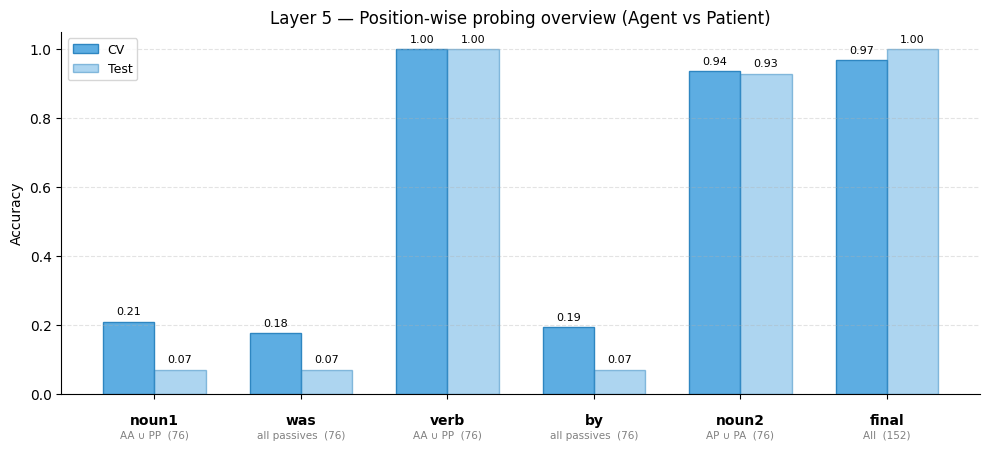

In [9]:
# --- Single overview: one bar per probe, training subset annotated ---
pos_order = ["noun1", "was", "verb", "by", "noun2", "final"]
subset_labels = {
    "noun1": "AA ∪ PP  (76)",
    "was":   "all passives  (76)",
    "verb":  "AA ∪ PP  (76)",
    "by":    "all passives  (76)",
    "noun2": "AP ∪ PA  (76)",
    "final": "All  (152)",
}

cv_vals   = [probe_results[p]["cv_accuracy"]  for p in pos_order]
test_vals = [probe_results[p]["test_accuracy"] for p in pos_order]

x = np.arange(len(pos_order))
width = 0.35
fig, ax = plt.subplots(figsize=(10, 5))

bars_cv   = ax.bar(x - width/2, cv_vals,   width, color="#5dade2", edgecolor="#2e86c1", label="CV")
bars_test = ax.bar(x + width/2, test_vals, width, color="#5dade2", edgecolor="#2e86c1", alpha=0.5, label="Test")

# Value labels on bars
for i in range(len(pos_order)):
    ax.text(x[i] - width/2, cv_vals[i] + 0.02,   f"{cv_vals[i]:.2f}",   ha="center", fontsize=8)
    ax.text(x[i] + width/2, test_vals[i] + 0.02, f"{test_vals[i]:.2f}", ha="center", fontsize=8)

# Position name as primary tick, training subset as secondary label below
ax.set_xticks(x)
ax.set_xticklabels(pos_order, fontsize=10, fontweight="bold")
ax.tick_params(axis="x", pad=10)
for i, p in enumerate(pos_order):
    ax.text(x[i], -0.12, subset_labels[p], ha="center", fontsize=7.5,
            color="gray", transform=ax.get_xaxis_transform())

ax.set_ylim(0.0, 1.05)
ax.set_ylabel("Accuracy")
ax.set_title(f"Layer {LAYER} — Position-wise probing overview (Agent vs Patient)", fontsize=12)
ax.grid(axis="y", linestyle="--", alpha=0.35)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.legend(fontsize=9)

plt.tight_layout()
plt.subplots_adjust(bottom=0.2)
plt.show()